# Vehicle Image Classification

- **Nama:** Mayang Gumelar
- **Email:** gumelarmayang@gmail.com
- **ID Dicoding:** CACC604D6X0437

---

Proyek ini bertujuan untuk melakukan klasifikasi gambar Vehicle (Kendaraan). Jenis varietas tersebut ada lima yakni: <br>
- Auto Rickshaws
- Bikes
- Cars
- Motorcycles
- Planes
- Ships
- Trains

**Model :** <br>
Dalam melakukan klasifikasi, akan digunakan model Convolutional Neural Network sederhana (bukan pretrained model) sehingga segala layer dapat diatur dan disesuaikan. Data akan di split menjadi train, test, dan val. Lalu model akan disimpan dalam 3 format berbeda yakni :<br>
- saved model
- tflite
- tfjs 

### **Import Library - Packages**

In [51]:
# Main ibrary for Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil
import io
import random
from importlib.metadata import distribution
from tqdm.notebook import tqdm
from random import sample
from shutil import copyfile
import joblib

# Image Preprocessing
import cv2 
from PIL import Image 
import skimage 
from skimage.transform import resize 
from skimage.transform import rotate, AffineTransform, warp 
from skimage import img_as_ubyte 
from skimage.exposure import adjust_gamma 
from skimage.util import random_noise 

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Cozy code
import warnings
warnings.simplefilter(action='ignore')


### **Data Loading**

In [2]:
# Load path
path = "D:/python/PyCharmMiscProject/AI ML DL/DBS 2026 - AI Eng/Fundamental Deep Learning/Vehicle-Image-Classification/Vehicles"
print("Lokasi Dataset: ", path)

Lokasi Dataset:  D:/python/PyCharmMiscProject/AI ML DL/DBS 2026 - AI Eng/Fundamental Deep Learning/Vehicle-Image-Classification/Vehicles


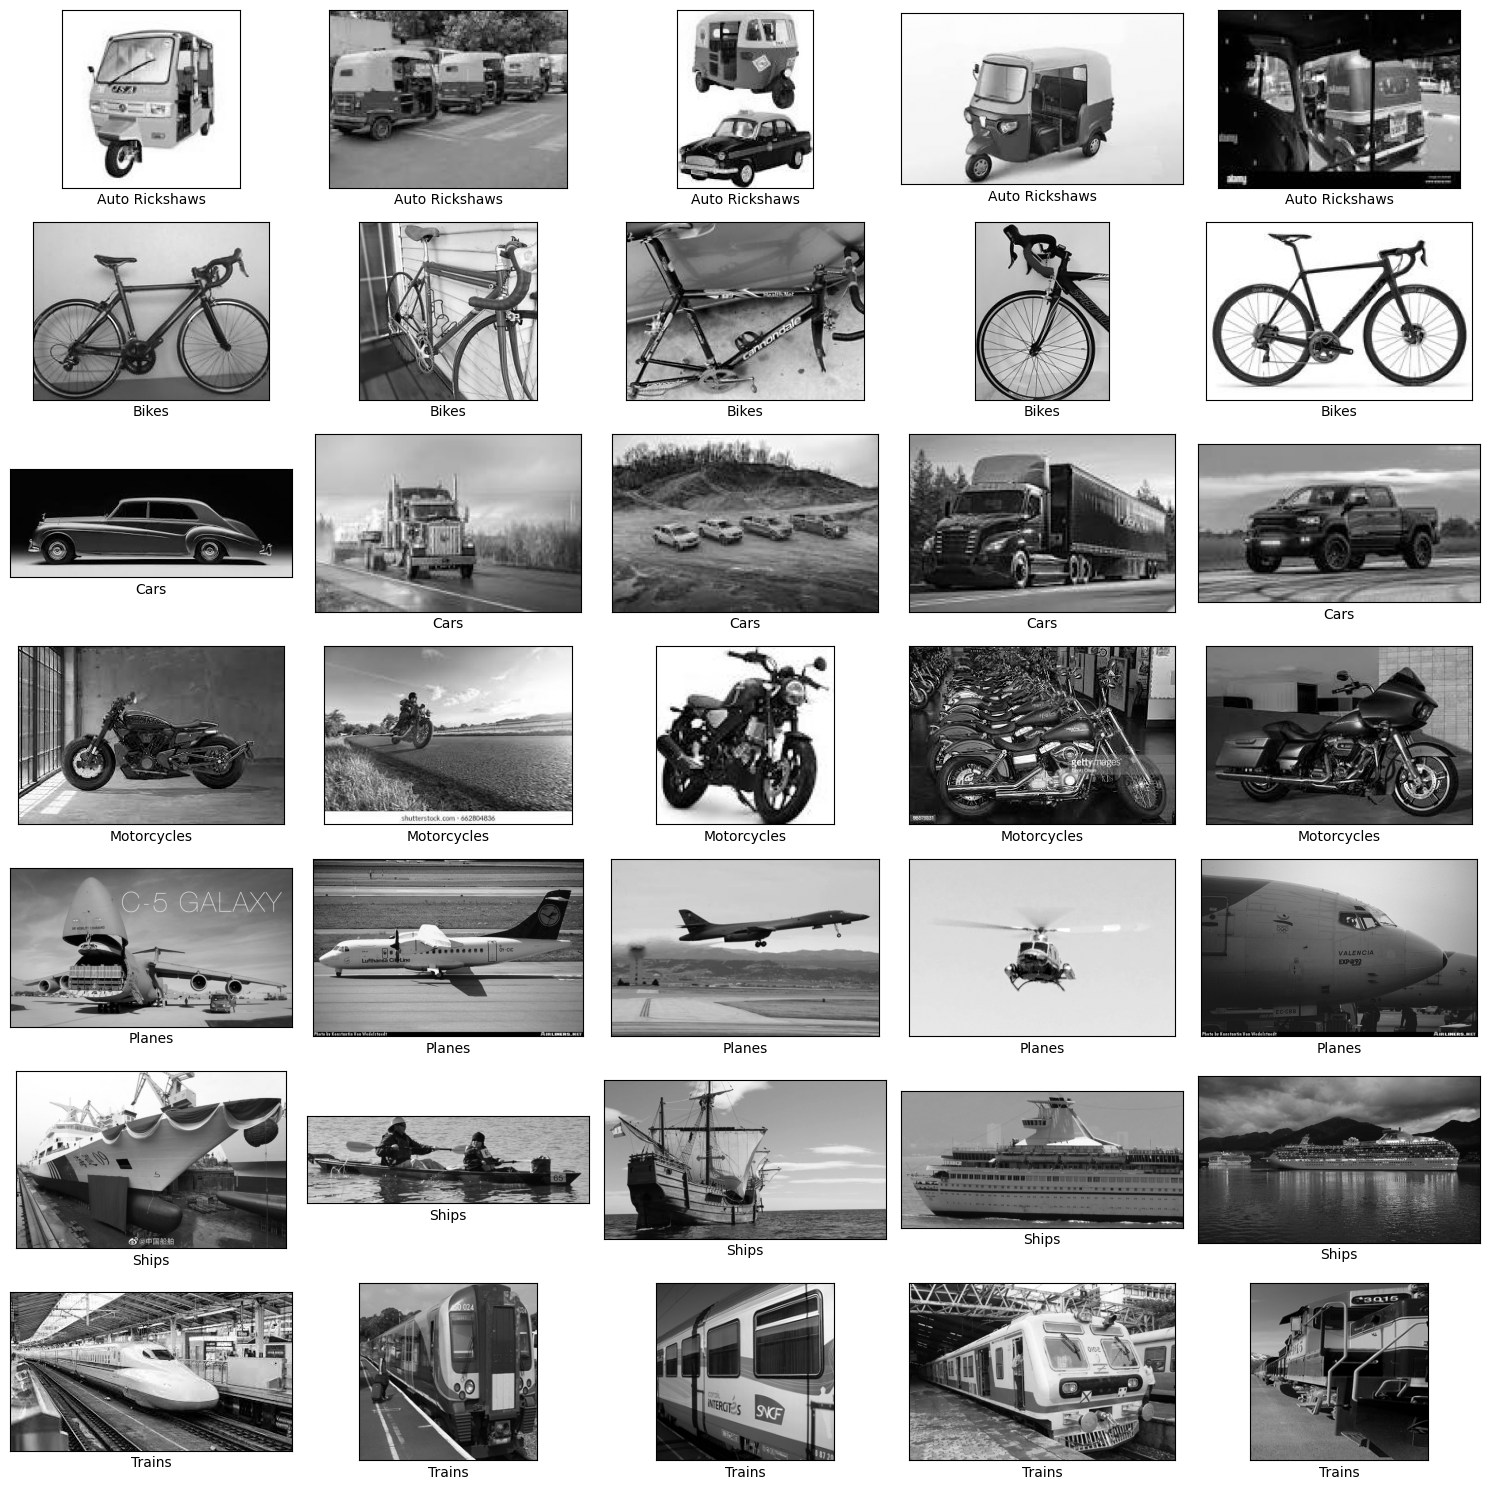

In [3]:
# Cek Dataset
vec_img = {}

path_main = "Vehicles"
for i in os.listdir(path_main):
    vec_img[i] = os.listdir(os.path.join(path_main, i))

# Menampilkan acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(vec_img.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_main)):
    images = np.random.choice(vec_img[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_main, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()


In [4]:
# Cek Resolusi Gambar
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images

        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")
        print("---------------")

    print(f"\nTotal: {total_images}")

print_images_resolution(path_main)

Auto Rickshaws: 800
- (421, 261)
- (2538, 2220)
- (162, 104)
- (1024, 675)
- (2048, 1355)
- (134, 140)
- (162, 122)
- (1280, 720)
- (225, 224)
- (5184, 3253)
- (162, 131)
- (2560, 1707)
- (171, 143)
- (149, 140)
- (1800, 1000)
- (94, 140)
- (750, 1000)
- (1333, 1000)
- (5182, 4613)
- (162, 97)
- (276, 183)
- (176, 160)
- (2048, 1467)
- (162, 115)
- (615, 439)
- (124, 140)
- (254, 198)
- (1024, 741)
- (162, 69)
- (259, 194)
- (900, 599)
- (233, 175)
- (162, 133)
- (266, 190)
- (5184, 3456)
- (267, 189)
- (221, 167)
- (476, 500)
- (670, 539)
- (162, 99)
- (162, 108)
- (279, 181)
- (117, 140)
- (284, 177)
- (141, 140)
- (162, 117)
- (270, 187)
- (1200, 1360)
- (299, 168)
- (162, 126)
- (256, 197)
- (262, 192)
- (291, 173)
- (600, 800)
- (1200, 667)
- (696, 542)
- (309, 163)
- (130, 140)
- (223, 166)
- (162, 92)
- (79, 140)
- (162, 101)
- (162, 110)
- (190, 126)
- (144, 138)
- (4000, 3000)
- (162, 119)
- (690, 430)
- (1536, 1152)
- (231, 218)
- (131, 140)
- (634, 386)
- (162, 85)
- (4019, 

**TOTAL ADA 5590 IMAGES DENGAN RESOLUSI YANG BERBEDA-BEAD**

### **Distribution Checking**

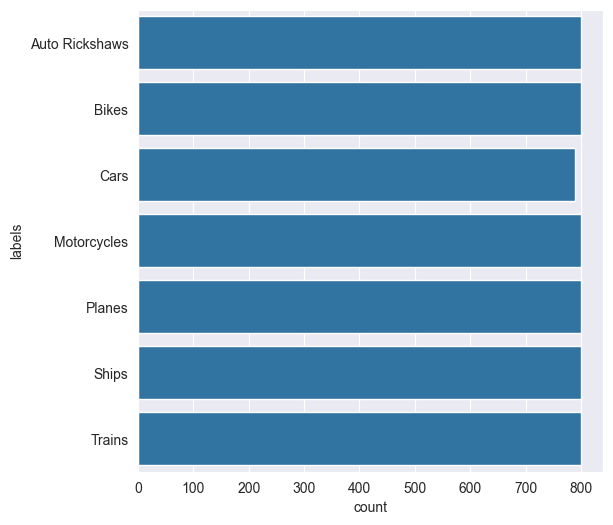

In [5]:
# definisikan path sumber
rice_path = "Vehicles/"

# buat daftar yang menyimpan data untuk setiap nama file, labels, dan path file
file_name = [] # simpan nama file
labels = [] # simpan nama kelas
full_path = [] # simpan jalur lengkap

# Dapatkan nama, label, path lalu simpan sbg dataframe
for path, subdirs, files in os.walk(rice_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name) # simpan nama file saja

distribution_train = pd.DataFrame({"path":full_path, "file_name":file_name, "labels":labels})

# plot distribusi gambar di 3setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

**Semua label memiliki rata-rata distribusi yang seimbang yakni berkisar pada 800 data gambar. Augmentasi dilakukan di semua label untuk memperkaya variasi images**

### **Data Augmentation**

Augmentasi yang akan dilakukan : <br>
- Putar Lawan Jarum Jam (Antriclockwise)
- Putar Searah Jarum Jam (Clockwise)
- Flip Atas Bawah (Flip Up Down)
- Penambahan Blur (Add Blur)

In [6]:
# Fungsi anticlockwise
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    sudut = random.randint(10, 180)
    return rotate(img, sudut)

# Fungsi clockwise
def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    sudut = random.randint(10, 180)
    return rotate(img, -sudut)

# Fungsi flip
def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    return np.flip(img)

# Blur Effect
def add_blur(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 244))
    return cv2.GaussianBlur(img, (9,9), 0)

In [10]:
# Membuat variabel transformasi
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'blurring image': add_blur,
                    'flip up down': flip_up_down}

def augment_img(images_path, augmented_path, images_to_generate):
    images = [] # Penyimpanan gambar yang telah melalui pra-pemrosesan

    # Baca nama gambar dari folder dan tambahkan path ke images[]
    for im in os.listdir(images_path):
        images.append(os.path.join(images_path, im))

    # jumalah gambar akan di augmentasi
    i=1

    while i<=images_to_generate:
        image=random.choice(images) # ambil dari list images[]
        try:
            original_image = cv2.imread(image)
            transformed_image=None
            n = 0
            transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang diterapkan

            while n <= transformation_count:
                key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
                transformed_image = transformations[key](original_image)
                n = n + 1

            new_image_path= "%s/augmented_%s.jpg" %(augmented_path, i)
            transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
            cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
            i =i+1
        except ValueError as e:
            print('could not read the',image ,':',e,'hence skipping it.')

In [8]:
# buat direktori baru untuk hasil augmentasi
def add_dir(name_dir : str):
    os.makedirs(name_dir, exist_ok=True)
    return f'{name_dir} berhasil dibuat'

# direktori untuk Hasil Augmentasi
add_dir('Vehicles/auto_rick_aug')
add_dir('Vehicles/bikes_aug')
add_dir('Vehicles/cars_aug')
add_dir('Vehicles/motor_aug')
add_dir('Vehicles/planes_aug')
add_dir('Vehicles/ships_aug')
add_dir('Vehicles/trains_aug')

'Vehicles/trains_aug berhasil dibuat'

In [ ]:
# Aug Auto Rickshaws
auto_rick = 'Vehicles/Auto Rickshaws'
auto_rick_aug = 'Vehicles/auto_rick_aug'
augment_img(auto_rick, auto_rick_aug, 800)

# Aug Bikes
bikes = 'Vehicles/Bikes'
bikes_aug = 'Vehicles/bikes_aug'
augment_img(bikes, bikes_aug, 800)

# Aug Cars
cars = 'Vehicles/Cars'
cars_aug = 'Vehicles/cars_aug'
augment_img(cars, cars_aug, 800)

# Aug Motorcycle
motor = 'Vehicles/Motorcycles'
motor_aug = 'Vehicles/motor_aug'
augment_img(motor, motor_aug, 800)

# Aug Planes
planes = 'Vehicles/Planes'
planes_aug = 'Vehicles/planes_aug'
augment_img(planes, planes_aug, 800)

# Aug Ships
ships = 'Vehicles/Ships'
ships_aug = 'Vehicles/ships_aug'
augment_img(ships, ships_aug, 800)

# Aug Trains
trains = 'Vehicles/Trains'
trains_aug = 'Vehicles/trains_aug'
augment_img(trains, trains_aug, 800)

In [14]:
# Pindahkan ke main folder
def move_to_main_dir(start, end):
    os.makedirs(end, exist_ok=True)

    for file in os.listdir(start):
        src = os.path.join(start, file)
        dst = os.path.join(end, file)

        if os.path.isfile(src) and file.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.move(src, dst)
    print('All images moved!')

In [15]:
move_to_main_dir(auto_rick_aug, auto_rick)
move_to_main_dir(bikes_aug, bikes)
move_to_main_dir(cars_aug, cars)
move_to_main_dir(motor_aug, motor)
move_to_main_dir(planes_aug, planes)
move_to_main_dir(ships_aug, ships)
move_to_main_dir(trains_aug, trains)

All images moved!
All images moved!
All images moved!
All images moved!
All images moved!
All images moved!
All images moved!


In [16]:
# Hapus folder augmentasi yang telah kosong
folder_del = [auto_rick_aug, bikes_aug, cars_aug, motor_aug, planes_aug, ships_aug, trains_aug]
for dir in folder_del:
    shutil.rmtree(dir)
print("Folder deleted")

Folder deleted


In [19]:
# cek distribusi akhir
def print_images_resolution(directory):
    total = 0
    print('Distribusi Images:')
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total += num_images
    
    print("------------------------------------")
    print(f"Total Gambar After Augmentasi : {total}")

print_images_resolution('Vehicles')

Distribusi Images:
Auto Rickshaws: 1600
Bikes: 1600
Cars: 1590
Motorcycles: 1600
Planes: 1600
Ships: 1600
Trains: 1600
------------------------------------
Total Gambar After Augmentasi : 11190


### **Data Preprocessing**

In [20]:
# Split Datset
# Variabel baru penampung dataset
my_path = 'Vehicles/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(my_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df = pd.DataFrame({"path":full_path, "file_name":file_name, "labels":labels})
df.groupby(['labels']).size()

labels
Auto Rickshaws    1600
Bikes             1600
Cars              1590
Motorcycles       1600
Planes            1600
Ships             1600
Trains            1600
dtype: int64

In [21]:
# Variabel yang digunakan pada pemisahan
X = df['path']
y= df['labels']

# Split dataset tahap 1
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=300)

# Split dataset tahap 2
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=300)

In [22]:
# Menyatukan ke dalam masing2 dataframe
df_tr = pd.DataFrame({'path':X_train, 'labels':y_train, 'set':'train'})
df_vl = pd.DataFrame({'path':X_val, 'labels':y_val, 'set':'val'})
df_te = pd.DataFrame({'path':X_test, 'labels':y_test, 'set':'test'})

In [23]:
# Gabung dataset
df_all = pd.concat([df_tr, df_vl, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel
print(df_all.sample(5))


set    labels        
test   Auto Rickshaws     249
       Bikes              233
       Cars               202
       Motorcycles        259
       Planes             235
       Ships              249
       Trains             252
train  Auto Rickshaws    1118
       Bikes             1132
       Cars              1147
       Motorcycles       1095
       Planes            1127
       Ships             1102
       Trains            1112
val    Auto Rickshaws     233
       Bikes              235
       Cars               241
       Motorcycles        246
       Planes             238
       Ships              249
       Trains             236
dtype: int64 


                                    path  labels    set
10844      Vehicles/Ships\Ship (271).jpg   Ships   test
1311     Vehicles/Ships\augmented_85.jpg   Ships  train
6123    Vehicles/Ships\augmented_323.jpg   Ships  train
7092   Vehicles/Planes\augmented_797.jpg  Planes  train
2544     Vehicles/Bikes\augmented_98.jpg   Bikes  t

In [52]:
# Buat variabel ImageDataGenerator untuk menormalkan gambar
train_val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = train_val_datagen.flow_from_dataframe(df_tr,
                                        x_col='path',
                                        y_col='labels',
                                        batch_size=32,
                                        target_size=(244, 244),
                                        class_mode='categorical',
                                        rotation_range=20,
                                        width_shift_range=0.2,
                                        height_shift_range=0.2,
                                        shear_range=0.2,
                                        zoom_range=0.2,
                                        horizontal_flip=True,
                                        fill_mode='nearest',
                                        shuffle=True)

val_gen = train_val_datagen.flow_from_dataframe(df_vl,
                                        x_col='path',
                                        y_col='labels',
                                        batch_size=32,
                                        target_size=(244, 244),
                                        class_mode='categorical',
                                        rotation_range=20,
                                        width_shift_range=0.2,
                                        height_shift_range=0.2,
                                        shear_range=0.2,
                                        zoom_range=0.2,
                                        horizontal_flip=True,
                                        fill_mode='nearest',
                                        shuffle=False)

test_gen = test_datagen.flow_from_dataframe(df_te,
                                            x_col='path',
                                            y_col='labels',
                                            batch_size=32,
                                            target_size=(244, 244),
                                            class_mode='categorical',
                                            shuffle=False)

Found 7831 validated image filenames belonging to 7 classes.
Found 1677 validated image filenames belonging to 7 classes.
Found 1679 validated image filenames belonging to 7 classes.


### **Modelling**

In [69]:
tf.keras.backend.clear_session()

In [70]:
tf.compat.v1.reset_default_graph()

# Inisialisasi MobileNet
mobilenet_v2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(244,244,3)
)

for layer in mobilenet_v2.layers:
    layer.trainable=False

model_cnn = tf.keras.Sequential([
    mobilenet_v2,

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 6, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,086,599 (11.77 MB)

 Trainable params: 828,615 (3.16 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [67]:
# Custome Callbacks
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        val_acc  = logs.get('val_accuracy')
        val_loss = logs.get('val_loss')
        
        if val_acc > 0.95 and val_loss < 0.4:
            print(f"\nEpoch {epoch+1}: Target tercapai! val_accuracy={val_acc:.4f}, val_loss={val_loss:.4f}")
            print("Training dihentikan!")
            self.model.stop_training = True

callbacks = [
    MyCallback(),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1)
]

In [71]:
history = model_cnn.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6984 - loss: 0.9334
Epoch 1: val_loss improved from None to 0.29188, saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.8202 - loss: 0.5547 - val_accuracy: 0.9040 - val_loss: 0.2919 - learning_rate: 0.0010
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.9227 - loss: 0.2432
Epoch 2: val_loss improved from 0.29188 to 0.22398, saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9298 - loss: 0.2403 - val_accuracy: 0.9296 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.9503 - loss: 0.1618
Epoch 3: val_loss did not improve from 0.22398
245/245 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.9489 - loss: 0.1652 - val_accuracy: 0.9320 - val_loss: 0.2463 - learning_rate: 0.0010
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.9686 - loss: 0.1085
Epoch 4: va

**PENJELASAN :** <br>
Hasil akhir dari Train Pertama adalah : <br>

- Accuracy Train : 99%
- Accuracy Val : 95%
- Loss Train : 2%
- Loss Val : 20%

### **Fine Tuning Model**

In [72]:
base_model = model_cnn.layers[0] 
base_model.trainable = True

fine_tune_at = 50 

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 20
total_epochs =  history.epoch[-1] + fine_tune_epochs

history_fine = model_cnn.fit(
    train_gen,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 9/28
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.9816 - loss: 0.0572
Epoch 9: val_loss improved from 0.19973 to 0.19497, saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.9815 - loss: 0.0571 - val_accuracy: 0.9499 - val_loss: 0.1950 - learning_rate: 1.0000e-05
Epoch 10/28
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.9817 - loss: 0.0562
Epoch 10: val_loss did not improve from 0.19497
245/245 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9834 - loss: 0.0515 - val_accuracy: 0.9499 - val_loss: 0.1956 - learning_rate: 1.0000e-05
Epoch 11/28
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.9832 - loss: 0.0536
Epoch 11: Target tercapai! val_accuracy=0.9511, val_loss=0.1955
Training dihentikan!

Epoch 11: val_loss did not improve from 0.19497
245/245 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9833 - loss: 0.0520 - val_accuracy: 0.9511 - val_loss: 0.1955 - learning_rate: 1.0000e-05
Restoring model weights from 

**PENJELASAN :** <br>
Hasil akhir dari Fine Tune adalah : <br>

- Accuracy Train : 98%
- Accuracy Val : 95%
- Loss Train : 5%
- Loss Val : 19%

### **Visualisasi**

#### **Base Training**

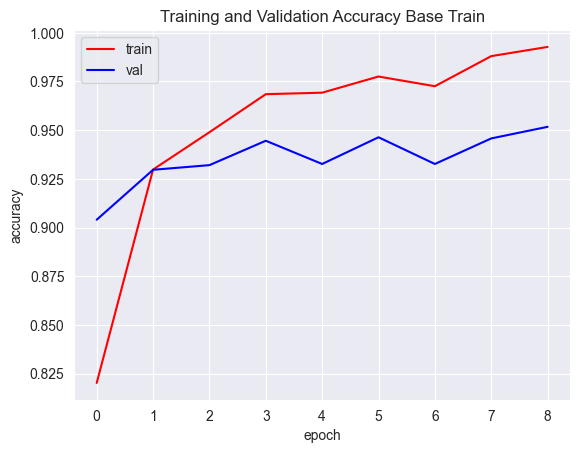

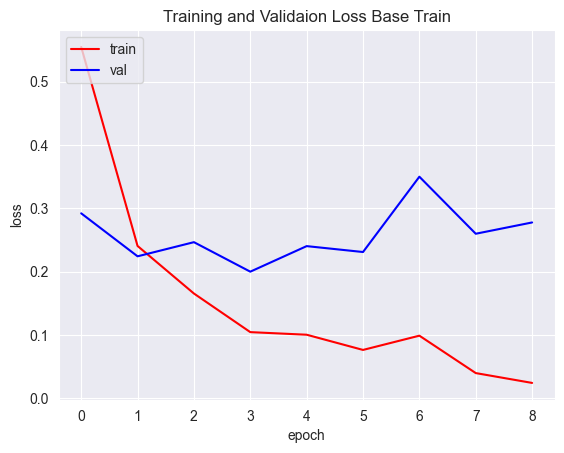

In [74]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validation Accuracy Base Train')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss Base Train')
plt.show()

#### **Fine Tune**

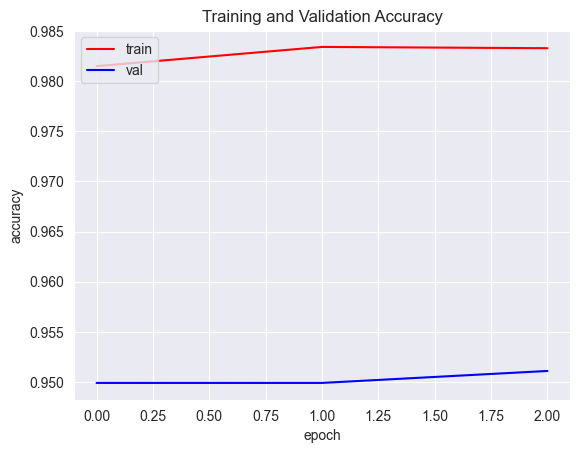

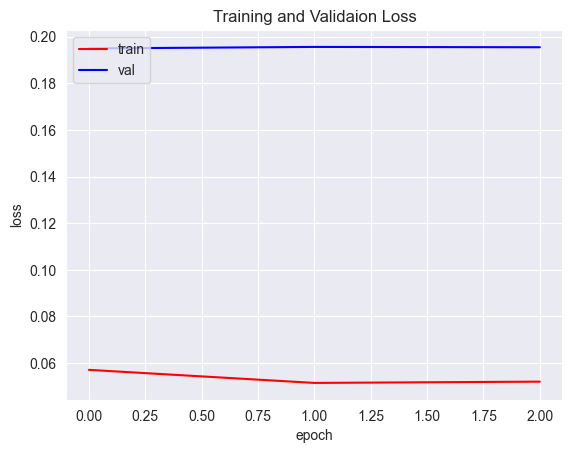

In [ ]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validation Accuracy Fine Tune')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss Fine Tune')
plt.show()

In [75]:
# Save model
model_cnn.save("model.keras")

### **Konversi Model**

Konversi ke Format : <br>
- Saved Model
- TF-Lite
- TFJS

In [76]:
# Format Saved Model
model_cnn.export("saved_model")

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  1608614111632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608614111440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608614109328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608614111248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608614111056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608659247248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608659250128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608659248976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608659249936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608659248208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1608659248016: TensorSpec(shape=(),

In [77]:
# Format TF-Lite
os.makedirs("tflite", exist_ok=True)

# Simpan model TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

# Simpan label.txt ke TFLite
class_names = list(train_gen.class_indices.keys())
with open("tflite/labels.txt", "w") as f:
    f.write("\n".join(class_names))

In [ ]:
# Format TFJS
INPUT_MODEL_PATH = "best_model.keras"

# Muat model
model = tf.keras.models.load_model(INPUT_MODEL_PATH)

# Convert model
tfjs.converters.save_keras_model(model, 'tfjs')

### **Inference**

Inference dilakukan dengan model format TFLITE

In [79]:
# Membaca file labels.txt
with open('tflite/labels.txt', 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

print("Label yang terdeteksi:", class_names)

Label yang terdeteksi: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [82]:
import numpy as np
import tensorflow as tf
from PIL import Image

def predict_tflite(image_path, model_path, labels):
    # 1. Load model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    # 2. Dapatkan detail input dan output
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # 3. Preprocessing Gambar
    img = Image.open(image_path).resize((244, 244))
    img_array = np.array(img, dtype=np.float32)
    img_array = img_array / 255.0 
    img_array = np.expand_dims(img_array, axis=0)

    # 4. Inference
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()

    # 5. Ambil Output
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_idx = np.argmax(output_data[0])
    
    return labels[predicted_idx], output_data[0][predicted_idx]

In [88]:
# Prediction 
list_image = [
    'data_test/Bike.jpg',
    'data_test/Plane.jpeg',
    'data_test/AutoRick.jpeg',
    'data_test/Vario.jpg'
]

for img_list in list_image:
    label_hasil, skor = predict_tflite(img_list, 'tflite/model.tflite', class_names)
    print(f"Hasil: {label_hasil} dengan keyakinan {skor*100:.2f}%")

Hasil: Bikes dengan keyakinan 100.00%
Hasil: Planes dengan keyakinan 100.00%
Hasil: Auto Rickshaws dengan keyakinan 100.00%
Hasil: Motorcycles dengan keyakinan 99.97%
